# Synthetic classification experiments for MinimaxSplit trees

This notebook is a **classification-only synthetic companion**  
It mirrors the paper's Section 4 setup:

- binary labels \(Y \in \{0,1\}\)
- **entropy-CART / C4.5 style** splitting by minimizing the **weighted sum of child entropies**
- **gini-CART** as an extra impurity baseline
- **MinimaxSplit for classification** by minimizing the **maximum weighted child entropy**
- evaluation centered on **expected log-loss**, **misclassification**, and **tree geometry**


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260331)

CFG = {
    "root_reps": 200,
    "curve_reps": 16,
    "atomic_reps": 12,
    "cyclic_reps": 10,
}

def expit(z):
    return 1.0 / (1.0 + np.exp(-z))

def clip_prob(p, eps=1e-8):
    return np.clip(p, eps, 1 - eps)

def entropy_binary(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

def gini_binary(p):
    p = np.clip(p, 0.0, 1.0)
    return 2.0 * p * (1.0 - p)

def bernoulli_logloss(y, p, eps=1e-8):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def expected_logloss_from_eta(eta, p, eps=1e-8):
    eta = np.clip(eta, eps, 1 - eps)
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(eta * np.log(p) + (1 - eta) * np.log(1 - p))

def brier_score(y, p):
    return np.mean((y - p) ** 2)

def classification_error(y, p):
    return np.mean((p >= 0.5) != y)

def draw_bernoulli(probs, rng):
    return (rng.random(len(probs)) < probs).astype(int)

def root_random_split_unif(x_sorted, rng):
    n = len(x_sorted)
    cut = rng.uniform(x_sorted.min(), x_sorted.max())
    nL = np.searchsorted(x_sorted, cut, side="right")
    prop = min(nL, n - nL) / n
    return {"prop": prop, "cut": cut}

def root_random_split_obs(x_sorted, rng):
    n = len(x_sorted)
    cut = rng.choice(x_sorted)
    nL = np.searchsorted(x_sorted, cut, side="right")
    prop = min(nL, n - nL) / n
    return {"prop": prop, "cut": cut}

def best_split_sorted_binary(y_sorted, x_sorted=None, min_leaf=1, criterion="entropy_cart"):
    """
    Evaluate all legal binary split points for binary labels y_sorted.

    Returns:
        split_index, score, min_child_prop

    split_index i means:
        left child = [:i]
        right child = [i:]
    """
    n = len(y_sorted)
    cpos = np.cumsum(y_sorted)

    best_score = np.inf
    best_idx = None
    best_prop = None

    for i in range(min_leaf, n - min_leaf + 1):
        if x_sorted is not None and x_sorted[i - 1] == x_sorted[i]:
            continue

        nL, nR = i, n - i
        pL = cpos[i - 1] / nL
        pR = (cpos[-1] - cpos[i - 1]) / nR
        prop = min(nL, nR) / n

        if criterion == "entropy_cart":
            score = nL * entropy_binary(pL) + nR * entropy_binary(pR)
        elif criterion == "gini_cart":
            score = nL * gini_binary(pL) + nR * gini_binary(pR)
        elif criterion == "entropy_minimax":
            score = max(nL * entropy_binary(pL), nR * entropy_binary(pR))
        else:
            raise ValueError(f"Unknown criterion: {criterion}")

        if score < best_score:
            best_score = score
            best_idx = i
            best_prop = prop

    return best_idx, best_score, best_prop

def best_root_split_stats(y_sorted, x_sorted, min_leaf=1, criterion="entropy_cart"):
    idx, score, prop = best_split_sorted_binary(
        y_sorted,
        x_sorted=x_sorted,
        min_leaf=min_leaf,
        criterion=criterion,
    )
    if idx is None:
        return None
    cut = 0.5 * (x_sorted[idx - 1] + x_sorted[idx])
    return {"prop": prop, "cut": cut, "score": score, "idx": idx}

class TreeNode:
    __slots__ = ("is_leaf", "pred", "feature", "split_val", "left", "right", "depth", "indices")

    def __init__(self, indices, depth):
        self.is_leaf = True
        self.pred = None
        self.feature = None
        self.split_val = None
        self.left = None
        self.right = None
        self.depth = depth
        self.indices = indices

class SimpleClassificationTree:
    """
    Simple axis-aligned binary classification tree with:
      - entropy-CART
      - gini-CART
      - minimax-entropy
      - greedy feature search, cyclic feature schedule, or random-dimension search
    """

    def __init__(self, criterion="entropy_cart", min_leaf=10, max_depth=6, split_mode="greedy"):
        self.criterion = criterion
        self.min_leaf = min_leaf
        self.max_depth = max_depth
        self.split_mode = split_mode
        self.root = None

    def fit(self, X, y):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        self.X = X.astype(float)
        self.y = np.asarray(y).astype(int)
        self.n_features_ = self.X.shape[1]
        self.root = self._build(np.arange(len(self.y)), depth=0)
        return self

    def _build(self, indices, depth):
        node = TreeNode(indices, depth)
        y_node = self.y[indices]
        n_pos = y_node.sum()
        # Laplace smoothing for stable probability predictions/log-loss
        node.pred = (n_pos + 0.5) / (len(indices) + 1.0)

        if depth >= self.max_depth:
            return node
        if len(indices) < 2 * self.min_leaf:
            return node
        if np.all(y_node == y_node[0]):
            return node

        if self.split_mode == "cyclic":
            candidate_features = [depth % self.n_features_]
        elif self.split_mode == "random_dimension":
            candidate_features = [int(rng.integers(self.n_features_))]
        else:
            candidate_features = list(range(self.n_features_))

        best = None
        best_score = np.inf

        for j in candidate_features:
            xj = self.X[indices, j]
            order = np.argsort(xj, kind="mergesort")
            sorted_indices = indices[order]
            x_sorted = self.X[sorted_indices, j]
            y_sorted = self.y[sorted_indices]

            idx, score, prop = best_split_sorted_binary(
                y_sorted,
                x_sorted=x_sorted,
                min_leaf=self.min_leaf,
                criterion=self.criterion,
            )
            if idx is None:
                continue

            if score < best_score:
                thr = 0.5 * (x_sorted[idx - 1] + x_sorted[idx])
                best_score = score
                best = (j, thr, sorted_indices[:idx], sorted_indices[idx:])

        if best is None:
            return node

        feat, thr, left_idx, right_idx = best
        if len(left_idx) == 0 or len(right_idx) == 0:
            return node

        node.is_leaf = False
        node.feature = feat
        node.split_val = float(thr)
        node.left = self._build(left_idx, depth + 1)
        node.right = self._build(right_idx, depth + 1)
        return node

    def _predict_prob_one(self, x, node):
        if node.is_leaf:
            return node.pred
        if x[node.feature] <= node.split_val:
            return self._predict_prob_one(x, node.left)
        return self._predict_prob_one(x, node.right)

    def predict_proba(self, X):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.array([self._predict_prob_one(row, self.root) for row in X])

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def leaf_sizes(self):
        return self._collect_leaf_sizes(self.root)

    def _collect_leaf_sizes(self, node):
        if node.is_leaf:
            return [len(node.indices)]
        return self._collect_leaf_sizes(node.left) + self._collect_leaf_sizes(node.right)

    def split_feature_counts(self):
        counts = np.zeros(self.n_features_, dtype=int)
        self._count_features(self.root, counts)
        return counts

    def _count_features(self, node, counts):
        if node.is_leaf:
            return
        counts[node.feature] += 1
        self._count_features(node.left, counts)
        self._count_features(node.right, counts)

class SimpleClassificationForest:
    """
    Lightweight forest wrapper that averages random-dimension trees.
    """

    def __init__(
        self,
        n_trees=40,
        criterion="entropy_minimax",
        min_leaf=10,
        max_depth=6,
        split_mode="random_dimension",
        bootstrap=True,
    ):
        self.n_trees = n_trees
        self.criterion = criterion
        self.min_leaf = min_leaf
        self.max_depth = max_depth
        self.split_mode = split_mode
        self.bootstrap = bootstrap
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        y = np.asarray(y).astype(int)
        n = len(y)

        self.trees = []
        for _ in range(self.n_trees):
            if self.bootstrap:
                idx = rng.integers(0, n, size=n)
            else:
                idx = np.arange(n)

            tree = SimpleClassificationTree(
                criterion=self.criterion,
                min_leaf=self.min_leaf,
                max_depth=self.max_depth,
                split_mode=self.split_mode,
            )
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)

        self.n_features_ = X.shape[1]
        return self

    def predict_proba(self, X):
        preds = np.column_stack([tree.predict_proba(X) for tree in self.trees])
        return preds.mean(axis=1)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def split_feature_counts(self):
        counts = np.zeros(self.n_features_, dtype=int)
        for tree in self.trees:
            counts += tree.split_feature_counts()
        return counts

def eta_smooth_1d(x, beta=3.0):
    return expit(beta * np.sin(4 * np.pi * x))

def eta_piecewise_1d(x):
    logit = np.piecewise(
        x,
        [x < 0.30, (x >= 0.30) & (x < 0.60), x >= 0.60],
        [2.0, -1.5, 1.0],
    )
    return expit(logit)

def eta_2d_additive(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    logit = 3.0 * (x1 - 0.5) + 2.0 * (np.abs(x2 - 0.5) - 0.20)
    return expit(logit)


## 1) Root-split ECP under pure classification noise

This is the direct classification analogue of the paper's pure-noise root-split experiment.

We simulate:

- \(X \sim \mathrm{Unif}(0,1)\)
- \(Y \sim \mathrm{Bernoulli}(\pi)\), independent of \(X\)

We compare:

- entropy-CART
- gini-CART
- minimax-entropy
- two random split baselines

The first row tracks **child-size imbalance**. The second row shows the **root split-location histogram** directly.


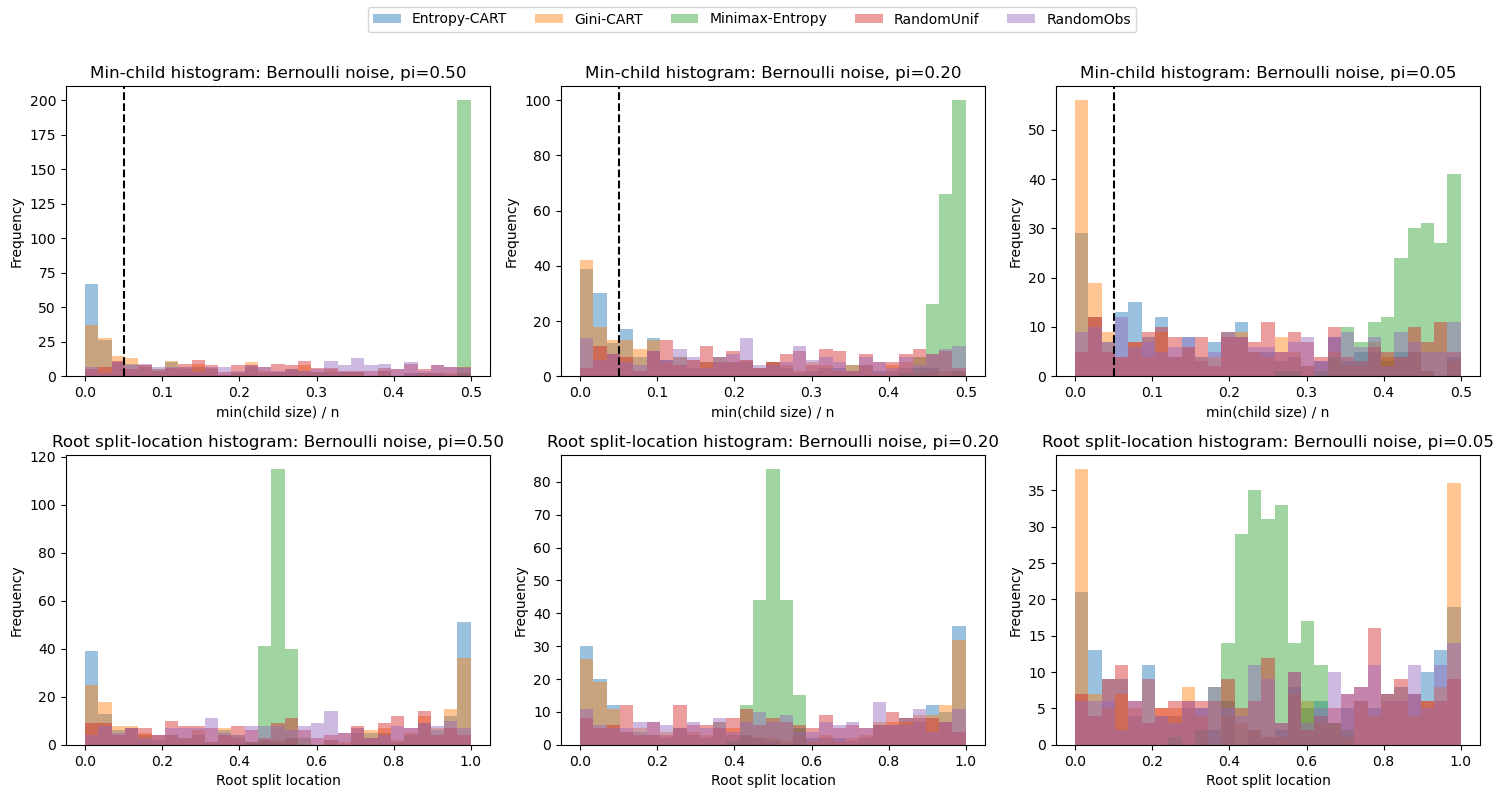

,pi,method,mean_min_child_prop,ecp_rate_(<=0.05),mean_split_location
12,0.05,Minimax-Entropy,0.441,0.000,0.499
13,0.05,RandomUnif,0.244,0.110,0.521
14,0.05,RandomObs,0.242,0.130,0.560
10,0.05,Entropy-CART,0.170,0.240,0.502
11,0.05,Gini-CART,0.146,0.420,0.487
7,0.20,Minimax-Entropy,0.479,0.000,0.500
8,0.20,RandomUnif,0.249,0.110,0.500
9,0.20,RandomObs,0.242,0.140,0.518
6,0.20,Gini-CART,0.141,0.365,0.506
5,0.20,Entropy-CART,0.128,0.405,0.506


In [2]:

n_samples = 500
edge_thr = 0.05
pi_grid = [0.50, 0.20, 0.05]

root_methods = {
    "Entropy-CART": lambda x, y: best_root_split_stats(
        y, x_sorted=x, min_leaf=1, criterion="entropy_cart"
    ),
    "Gini-CART": lambda x, y: best_root_split_stats(
        y, x_sorted=x, min_leaf=1, criterion="gini_cart"
    ),
    "Minimax-Entropy": lambda x, y: best_root_split_stats(
        y, x_sorted=x, min_leaf=1, criterion="entropy_minimax"
    ),
    "RandomUnif": lambda x, y: root_random_split_unif(x, rng),
    "RandomObs": lambda x, y: root_random_split_obs(x, rng),
}

root_results = {}
for pi in pi_grid:
    store = {k: {"prop": [], "cut": []} for k in root_methods}
    for _ in range(CFG["root_reps"]):
        x = rng.random(n_samples)
        y = draw_bernoulli(np.full(n_samples, pi), rng)
        order = np.argsort(x)
        x_sorted = x[order]
        y_sorted = y[order]

        for name, fn in root_methods.items():
            out = fn(x_sorted, y_sorted)
            if out is not None:
                store[name]["prop"].append(out["prop"])
                store[name]["cut"].append(out["cut"])

    root_results[pi] = {
        k: {field: np.asarray(vals) for field, vals in v.items()}
        for k, v in store.items()
    }

fig, axes = plt.subplots(2, len(pi_grid), figsize=(5 * len(pi_grid), 8), sharex=False)

for col, pi in enumerate(pi_grid):
    for name, vals in root_results[pi].items():
        axes[0, col].hist(vals["prop"], bins=np.linspace(0, 0.5, 30), alpha=0.45, label=name)
        axes[1, col].hist(vals["cut"], bins=np.linspace(0, 1, 30), alpha=0.45, label=name)

    axes[0, col].axvline(edge_thr, color="k", linestyle="--", linewidth=1.5)
    axes[0, col].set_title(f"Min-child histogram: Bernoulli noise, pi={pi:.2f}")
    axes[1, col].set_title(f"Root split-location histogram: Bernoulli noise, pi={pi:.2f}")
    axes[0, col].set_xlabel("min(child size) / n")
    axes[1, col].set_xlabel("Root split location")
    axes[0, col].set_ylabel("Frequency")
    axes[1, col].set_ylabel("Frequency")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, frameon=True)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

summary_rows = []
for pi in pi_grid:
    for name, vals in root_results[pi].items():
        summary_rows.append({
            "pi": pi,
            "method": name,
            "mean_min_child_prop": vals["prop"].mean(),
            "ecp_rate_(<=0.05)": np.mean(vals["prop"] <= edge_thr),
            "mean_split_location": vals["cut"].mean(),
        })

root_summary = pd.DataFrame(summary_rows)
root_summary.sort_values(["pi", "mean_min_child_prop"], ascending=[True, False]).round(3)


## 2) Piecewise 1D probability signal

 real 1D classification function.

We use the **piecewise** signal `eta_piecewise_1d`, which is constant on three intervals:
- high class-1 probability on \([0, 0.30)\)
- low class-1 probability on \([0.30, 0.60)\)
- moderate class-1 probability on \([0.60, 1]\)

This makes it easy to see whether the fitted tree is cutting in the right places and whether the predicted probabilities remain stable across repeated fits.


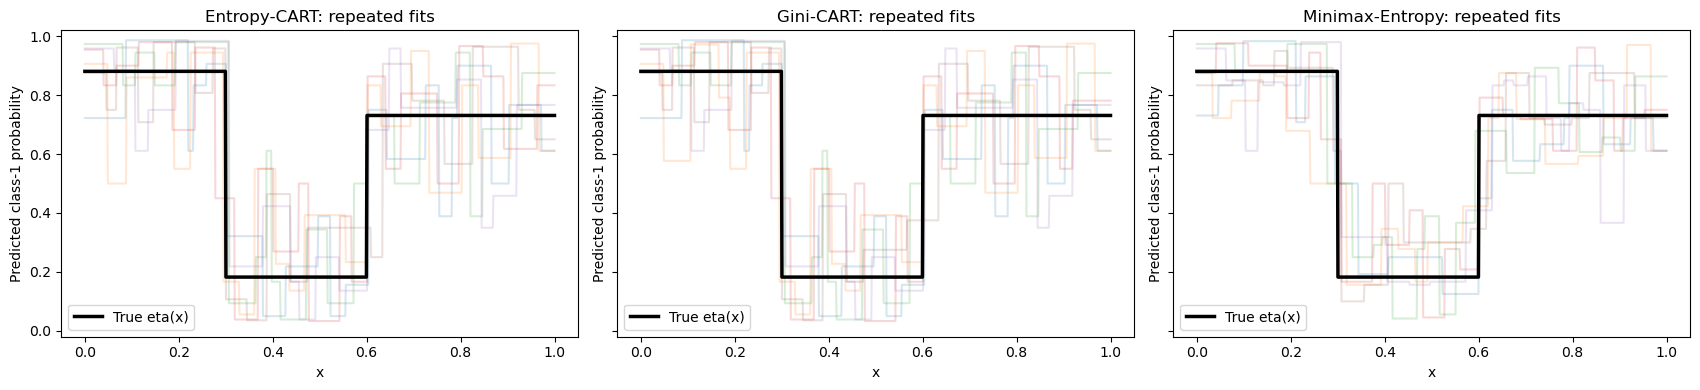

In [3]:

x_grid = np.linspace(0, 1, 800)
X_grid = x_grid.reshape(-1, 1)
eta_grid = eta_piecewise_1d(x_grid)

overlay_depth = 6
overlay_reps = 6
overlay_n = 250

overlay_methods = {
    "Entropy-CART": dict(criterion="entropy_cart", split_mode="greedy"),
    "Gini-CART": dict(criterion="gini_cart", split_mode="greedy"),
    "Minimax-Entropy": dict(criterion="entropy_minimax", split_mode="greedy"),
}

overlay_preds = {k: [] for k in overlay_methods}

for _ in range(overlay_reps):
    X_train = rng.random((overlay_n, 1))
    eta_train = eta_piecewise_1d(X_train[:, 0])
    y_train = draw_bernoulli(eta_train, rng)

    for name, kwargs in overlay_methods.items():
        tree = SimpleClassificationTree(
            min_leaf=8,
            max_depth=overlay_depth,
            criterion=kwargs["criterion"],
            split_mode=kwargs["split_mode"],
        )
        tree.fit(X_train, y_train)
        overlay_preds[name].append(tree.predict_proba(X_grid))

fig, axes = plt.subplots(1, len(overlay_methods), figsize=(5.7 * len(overlay_methods), 4), sharey=True)
if len(overlay_methods) == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, overlay_preds.items()):
    for p in preds:
        ax.plot(x_grid, p, alpha=0.18)
    ax.plot(x_grid, eta_grid, color="black", linewidth=2.5, label="True eta(x)")
    ax.set_title(f"{name}: repeated fits")
    ax.set_xlabel("x")
    ax.set_ylabel("Predicted class-1 probability")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()

plt.tight_layout()
plt.show()


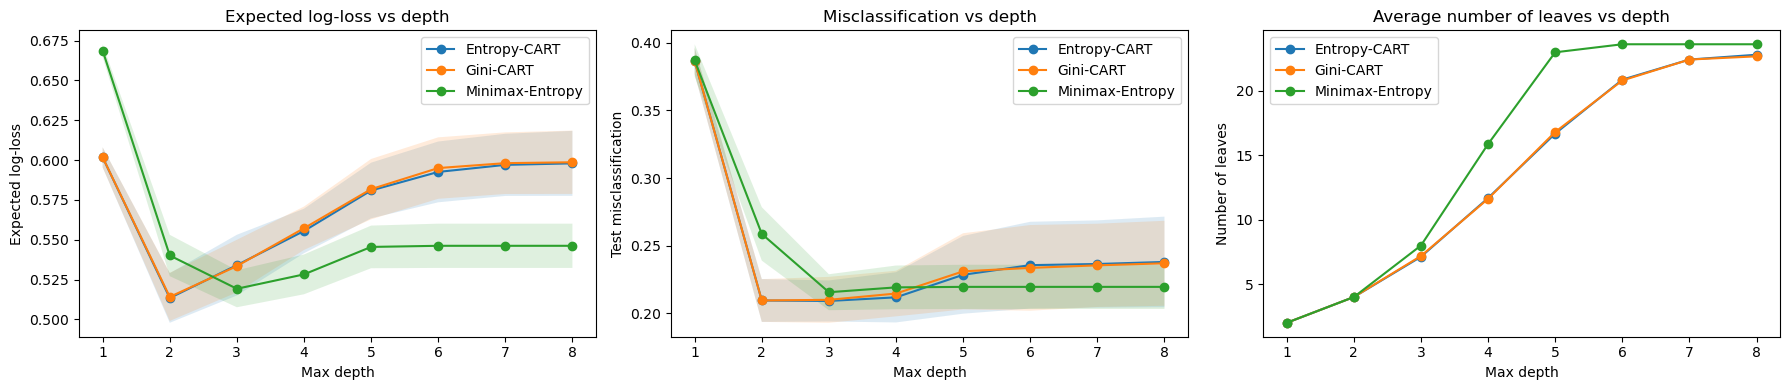

,method,depth,logloss_mean,logloss_sd,elogloss_mean,elogloss_sd,misclass_mean,misclass_sd,leaf_mean,leaf_std,n_leaves
0,Entropy-CART,1,0.6031,0.0093,0.6017,0.0063,0.3866,0.0098,125.0000,52.7500,2.0000
1,Entropy-CART,2,0.5139,0.0211,0.5135,0.0155,0.2093,0.0158,62.5000,31.2808,4.0000
2,Entropy-CART,3,0.5371,0.0273,0.5341,0.0191,0.2089,0.0152,35.1562,22.3369,7.1250
3,Entropy-CART,4,0.5582,0.0262,0.5555,0.0140,0.2116,0.0186,21.6143,13.1096,11.6875
4,Entropy-CART,5,0.5827,0.0253,0.5809,0.0174,0.2283,0.0288,15.1683,7.6351,16.6875
5,Entropy-CART,6,0.5940,0.0264,0.5926,0.0191,0.2355,0.0321,12.0805,4.8025,20.8750
6,Entropy-CART,7,0.5977,0.0258,0.5970,0.0195,0.2363,0.0323,11.1913,3.8250,22.4375
7,Entropy-CART,8,0.5990,0.0275,0.5980,0.0204,0.2378,0.0335,10.9862,3.5907,22.8125
8,Gini-CART,1,0.6031,0.0093,0.6017,0.0063,0.3866,0.0098,125.0000,52.7500,2.0000
9,Gini-CART,2,0.5143,0.0208,0.5142,0.0151,0.2093,0.0158,62.5000,31.4818,4.0000


In [4]:

depth_grid = np.arange(1, 9)
n_train = 250
n_test = 2000
curve_methods = {
    "Entropy-CART": dict(criterion="entropy_cart", split_mode="greedy"),
    "Gini-CART": dict(criterion="gini_cart", split_mode="greedy"),
    "Minimax-Entropy": dict(criterion="entropy_minimax", split_mode="greedy"),
}

rows = []
for rep in range(CFG["curve_reps"]):
    X_test = rng.random((n_test, 1))
    eta_test = eta_piecewise_1d(X_test[:, 0])
    y_test = draw_bernoulli(eta_test, rng)

    X_train = rng.random((n_train, 1))
    eta_train = eta_piecewise_1d(X_train[:, 0])
    y_train = draw_bernoulli(eta_train, rng)

    for depth in depth_grid:
        for name, kwargs in curve_methods.items():
            tree = SimpleClassificationTree(
                min_leaf=8,
                max_depth=int(depth),
                criterion=kwargs["criterion"],
                split_mode=kwargs["split_mode"],
            )
            tree.fit(X_train, y_train)
            p_test = tree.predict_proba(X_test)
            leaf_sizes = np.asarray(tree.leaf_sizes())

            rows.append({
                "rep": rep,
                "depth": depth,
                "method": name,
                "logloss": bernoulli_logloss(y_test, p_test),
                "expected_logloss": expected_logloss_from_eta(eta_test, p_test),
                "brier": brier_score(y_test, p_test),
                "misclass": classification_error(y_test, p_test),
                "leaf_mean": leaf_sizes.mean(),
                "leaf_std": leaf_sizes.std(),
                "n_leaves": len(leaf_sizes),
            })

curve_df = pd.DataFrame(rows)

agg = (
    curve_df.groupby(["method", "depth"])
    .agg(
        logloss_mean=("logloss", "mean"),
        logloss_sd=("logloss", "std"),
        elogloss_mean=("expected_logloss", "mean"),
        elogloss_sd=("expected_logloss", "std"),
        misclass_mean=("misclass", "mean"),
        misclass_sd=("misclass", "std"),
        leaf_mean=("leaf_mean", "mean"),
        leaf_std=("leaf_std", "mean"),
        n_leaves=("n_leaves", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for name in curve_methods:
    sub = agg[agg["method"] == name]
    axes[0].plot(sub["depth"], sub["elogloss_mean"], marker="o", label=name)
    axes[0].fill_between(
        sub["depth"],
        sub["elogloss_mean"] - sub["elogloss_sd"],
        sub["elogloss_mean"] + sub["elogloss_sd"],
        alpha=0.15,
    )

    axes[1].plot(sub["depth"], sub["misclass_mean"], marker="o", label=name)
    axes[1].fill_between(
        sub["depth"],
        sub["misclass_mean"] - sub["misclass_sd"],
        sub["misclass_mean"] + sub["misclass_sd"],
        alpha=0.15,
    )

    axes[2].plot(sub["depth"], sub["n_leaves"], marker="o", label=name)

axes[0].set_title("Expected log-loss vs depth")
axes[0].set_xlabel("Max depth")
axes[0].set_ylabel("Expected log-loss")

axes[1].set_title("Misclassification vs depth")
axes[1].set_xlabel("Max depth")
axes[1].set_ylabel("Test misclassification")

axes[2].set_title("Average number of leaves vs depth")
axes[2].set_xlabel("Max depth")
axes[2].set_ylabel("Number of leaves")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

agg.round(4).head(18)


## 3) Leaf balance vs depth

The paper's regression section emphasizes that end-cuts propagate imbalance down the tree.

Here we track the same geometry in classification by looking at:

- average leaf size
- standard deviation of leaf size

Balanced trees should drive **both** down smoothly as depth increases.


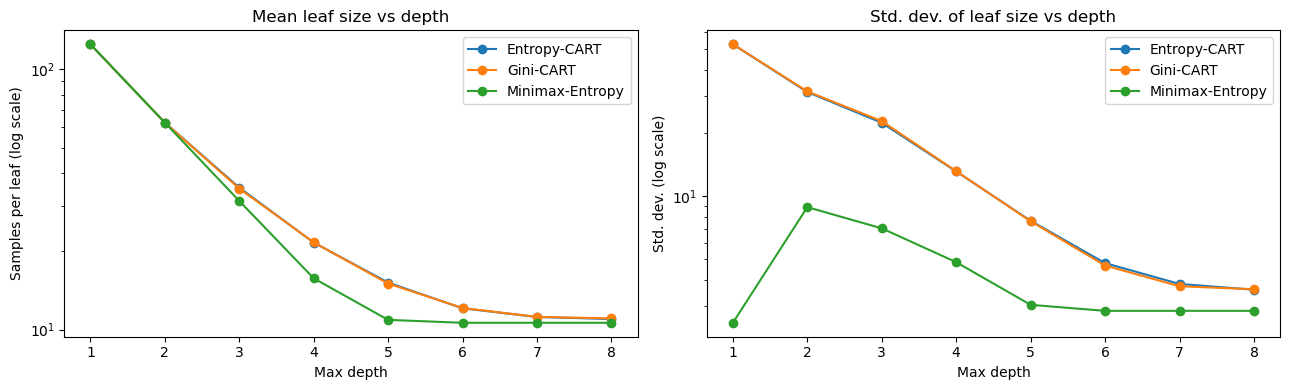

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for name in curve_methods:
    sub = agg[agg["method"] == name]
    axes[0].plot(sub["depth"], sub["leaf_mean"], marker="o", label=name)
    axes[1].plot(sub["depth"], sub["leaf_std"], marker="o", label=name)

axes[0].set_yscale("log")
axes[1].set_yscale("log")
axes[0].set_title("Mean leaf size vs depth")
axes[1].set_title("Std. dev. of leaf size vs depth")
axes[0].set_xlabel("Max depth")
axes[1].set_xlabel("Max depth")
axes[0].set_ylabel("Samples per leaf (log scale)")
axes[1].set_ylabel("Std. dev. (log scale)")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


## 4) Continuous vs atomic covariates

Section 4 of the paper separates the **marginally atomless** and **purely atomic** covariate settings.

This experiment mirrors that distinction empirically by comparing:

- **continuous** \(X \sim \mathrm{Unif}(0,1)\)
- **atomic** \(X\) sampled from a fixed grid with replacement

The underlying 1D signal remains the same **piecewise** class-probability function.


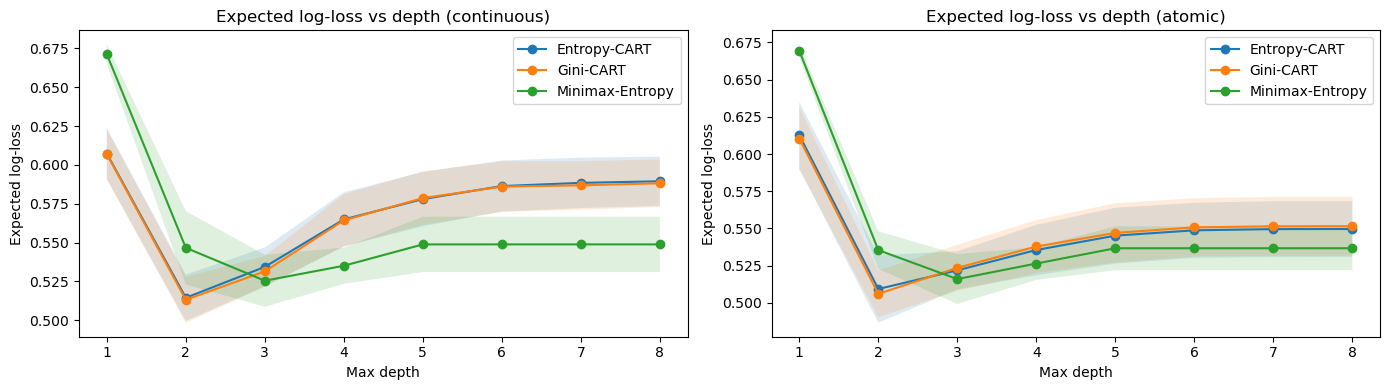

In [6]:

depth_grid_atomic = np.arange(1, 9)
regimes = ["continuous", "atomic"]
atomic_grid = np.linspace(0, 1, 41)

rows = []
for regime in regimes:
    for rep in range(CFG["atomic_reps"]):
        if regime == "continuous":
            X_train = rng.random((250, 1))
            X_test = rng.random((2000, 1))
        else:
            X_train = rng.choice(atomic_grid, size=250, replace=True).reshape(-1, 1)
            X_test = rng.choice(atomic_grid, size=2000, replace=True).reshape(-1, 1)

        eta_train = eta_piecewise_1d(X_train[:, 0])
        eta_test = eta_piecewise_1d(X_test[:, 0])
        y_train = draw_bernoulli(eta_train, rng)
        y_test = draw_bernoulli(eta_test, rng)

        for depth in depth_grid_atomic:
            for name, kwargs in curve_methods.items():
                tree = SimpleClassificationTree(
                    min_leaf=8,
                    max_depth=int(depth),
                    criterion=kwargs["criterion"],
                    split_mode=kwargs["split_mode"],
                )
                tree.fit(X_train, y_train)
                p_test = tree.predict_proba(X_test)

                rows.append({
                    "regime": regime,
                    "depth": depth,
                    "method": name,
                    "expected_logloss": expected_logloss_from_eta(eta_test, p_test),
                    "misclass": classification_error(y_test, p_test),
                })

atomic_df = pd.DataFrame(rows)
atomic_agg = (
    atomic_df.groupby(["regime", "method", "depth"])
    .agg(
        elogloss_mean=("expected_logloss", "mean"),
        elogloss_sd=("expected_logloss", "std"),
        misclass_mean=("misclass", "mean"),
        misclass_sd=("misclass", "std"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for ax, regime in zip(axes, regimes):
    sub_reg = atomic_agg[atomic_agg["regime"] == regime]
    for name in curve_methods:
        sub = sub_reg[sub_reg["method"] == name]
        ax.plot(sub["depth"], sub["elogloss_mean"], marker="o", label=name)
        ax.fill_between(
            sub["depth"],
            sub["elogloss_mean"] - sub["elogloss_sd"],
            sub["elogloss_mean"] + sub["elogloss_sd"],
            alpha=0.15,
        )
    ax.set_title(f"Expected log-loss vs depth ({regime})")
    ax.set_xlabel("Max depth")
    ax.set_ylabel("Expected log-loss")
    ax.legend()

plt.tight_layout()
plt.show()


## 5) Optional 2D experiment: cyclic, greedy, and random-dimension forest

The theory in the paper is built around the **cyclic** classification construction, and the paper also discusses a **random-dimension forest** analogue.

This last experiment uses a 2D additive logit model and compares:

- entropy-CART with greedy feature search
- gini-CART with greedy feature search
- minimax-entropy with greedy feature search
- minimax-entropy with cyclic feature search
- a **random-dimension forest** built from random-dimension Minimax trees


                             expected_logloss  misclass  share_feature_0  \
method                                                                     
Entropy-CART (greedy)                  0.7275    0.3827           0.5140   
Gini-CART (greedy)                     0.7291    0.3886           0.5311   
Minimax forest (random-dim)            0.6230    0.3340           0.4976   
Minimax-Entropy (cyclic)               0.6521    0.3424           0.6126   
Minimax-Entropy (greedy)               0.6599    0.3516           0.7101   

                             share_feature_1  
method                                        
Entropy-CART (greedy)                 0.4860  
Gini-CART (greedy)                    0.4689  
Minimax forest (random-dim)           0.5024  
Minimax-Entropy (cyclic)              0.3874  
Minimax-Entropy (greedy)              0.2899  


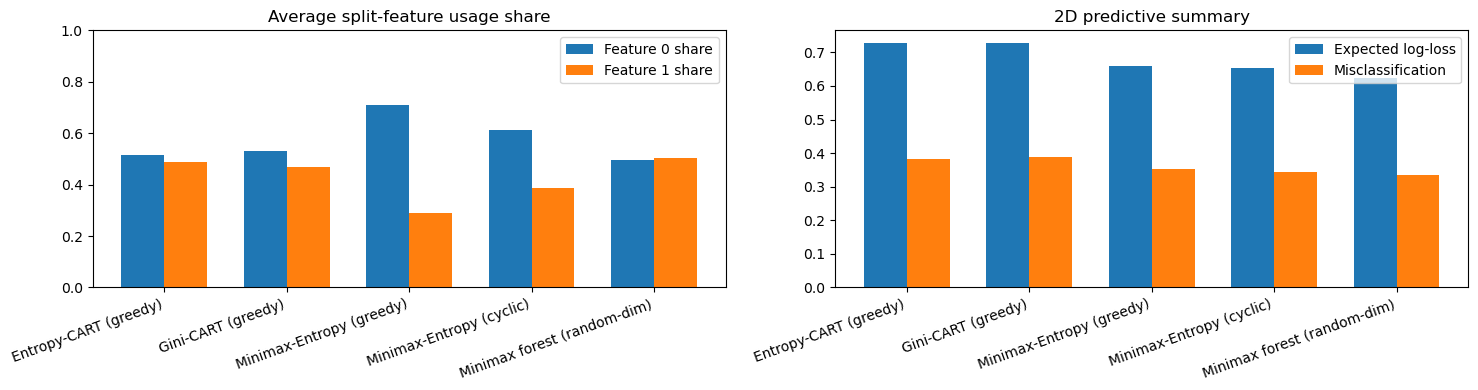

In [7]:

methods_2d = {
    "Entropy-CART (greedy)": dict(model="tree", criterion="entropy_cart", split_mode="greedy"),
    "Gini-CART (greedy)": dict(model="tree", criterion="gini_cart", split_mode="greedy"),
    "Minimax-Entropy (greedy)": dict(model="tree", criterion="entropy_minimax", split_mode="greedy"),
    "Minimax-Entropy (cyclic)": dict(model="tree", criterion="entropy_minimax", split_mode="cyclic"),
    "Minimax forest (random-dim)": dict(
        model="forest",
        criterion="entropy_minimax",
        split_mode="random_dimension",
        n_trees=40,
    ),
}

rows = []
feature_usage = {name: [] for name in methods_2d}

for rep in range(CFG["cyclic_reps"]):
    X_train = rng.random((350, 2))
    X_test = rng.random((1800, 2))
    eta_train = eta_2d_additive(X_train)
    eta_test = eta_2d_additive(X_test)
    y_train = draw_bernoulli(eta_train, rng)
    y_test = draw_bernoulli(eta_test, rng)

    for name, kwargs in methods_2d.items():
        if kwargs["model"] == "tree":
            model = SimpleClassificationTree(
                min_leaf=10,
                max_depth=6,
                criterion=kwargs["criterion"],
                split_mode=kwargs["split_mode"],
            )
        else:
            model = SimpleClassificationForest(
                n_trees=kwargs["n_trees"],
                criterion=kwargs["criterion"],
                min_leaf=10,
                max_depth=6,
                split_mode=kwargs["split_mode"],
                bootstrap=True,
            )

        model.fit(X_train, y_train)
        p_test = model.predict_proba(X_test)
        counts = model.split_feature_counts()
        total_splits = counts.sum()

        rows.append({
            "method": name,
            "expected_logloss": expected_logloss_from_eta(eta_test, p_test),
            "misclass": classification_error(y_test, p_test),
            "share_feature_0": (counts[0] / total_splits) if total_splits > 0 else np.nan,
            "share_feature_1": (counts[1] / total_splits) if total_splits > 0 else np.nan,
        })
        feature_usage[name].append(counts)

cyclic_df = pd.DataFrame(rows)
cyclic_summary = cyclic_df.groupby("method").mean(numeric_only=True).round(4)
print(cyclic_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

order = list(methods_2d.keys())
means0 = [cyclic_summary.loc[m, "share_feature_0"] for m in order]
means1 = [cyclic_summary.loc[m, "share_feature_1"] for m in order]
x = np.arange(len(order))
width = 0.35

axes[0].bar(x - width / 2, means0, width, label="Feature 0 share")
axes[0].bar(x + width / 2, means1, width, label="Feature 1 share")
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, rotation=20, ha="right")
axes[0].set_ylim(0, 1)
axes[0].set_title("Average split-feature usage share")
axes[0].legend()

elog = [cyclic_summary.loc[m, "expected_logloss"] for m in order]
mis = [cyclic_summary.loc[m, "misclass"] for m in order]

axes[1].bar(x - width / 2, elog, width, label="Expected log-loss")
axes[1].bar(x + width / 2, mis, width, label="Misclassification")
axes[1].set_xticks(x)
axes[1].set_xticklabels(order, rotation=20, ha="right")
axes[1].set_title("2D predictive summary")
axes[1].legend()

plt.tight_layout()
plt.show()
